# 1 Типы признаков и шкалы измерения
## Задание 1
### Загрузка данных в pandas DataFrame

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/extreme_pollution.csv"
df = pd.read_csv(DATA_PATH, sep=";", quotechar='"')

print(df.shape)
df.head()

(7671, 13)


,id,period,subject,municipality,settlement,oktmo,water_body,indicator,hazard_class,cnt_cases,value_min,value_max,unit
0,1,2008-01-31,Камчатский край,Усть-Камчатский район,п. Козыревск,3.061941e+10,р. Камчатка,Кадмий,2,1,6.0,6.0,ПДК
1,2,2008-01-31,Курганская область,Курган,г. Курган,3.770100e+10,вдхр. Курганское,Марганец,4,1,60.0,60.0,ПДК
2,3,2008-01-31,Московская область,Королёв,г. Королев,4.673400e+10,"ручей, впадающий в реку Клязьму",Нефть и нефтепродукты,3,8,71.0,100.0,ПДК
3,4,2008-01-31,Мурманская область,Печенгский муниципальный район,пгт. Никель,4.751500e+10,р. Колос-Йоки,Никель,3,1,60.0,60.0,ПДК
4,5,2008-01-31,Мурманская область,Городской округ город Мончегорск с подведомств...,г. Мончегорск,4.771500e+10,р. Нюдуай,Водородный показатель (pH),NaN,1,9.9,9.9,pH


### 1.1.1 Указание типа шкалы

In [8]:
# Словарь с типами шкал 
scale_types = {
    'id': 'номинальная',
    'period': 'интервальная',
    'subject': 'номинальная',
    'municipality': 'номинальная',
    'settlement': 'номинальная',
    'oktmo': 'номинальная',
    'water_body': 'номинальная',
    'indicator': 'номинальная',
    'hazard_class': 'порядковая',
    'cnt_cases': 'абсолютная',
    'value_min': 'абсолютная',
    'value_max': 'абсолютная',
    'unit': 'номинальная'
}

# Преобразуем в DataFrame
import pandas as pd
scale_df = pd.DataFrame(list(scale_types.items()), columns=['Признак', 'Тип шкалы'])
print(scale_df.to_string(index=False))

     Признак    Тип шкалы
          id  номинальная
      period интервальная
     subject  номинальная
municipality  номинальная
  settlement  номинальная
       oktmo  номинальная
  water_body  номинальная
   indicator  номинальная
hazard_class   порядковая
   cnt_cases   абсолютная
   value_min   абсолютная
   value_max   абсолютная
        unit  номинальная


### 1.1.2 Анализ двух признаков с разными шкалами
##### **Выберем порядковый признак hazard_class и абсолютный cnt_cases. Вычислим для них среднее, медиану и моду**

In [3]:
# Выбор признаков
ordinal_col = 'hazard_class'
absolute_col = 'cnt_cases'

# Приведение к числовому типу 
df[ordinal_col] = pd.to_numeric(df[ordinal_col], errors='coerce')
df[absolute_col] = pd.to_numeric(df[absolute_col], errors='coerce')

# Удалим пропуски, если они появились
ord_data = df[ordinal_col].dropna()
abs_data = df[absolute_col].dropna()

# Расчёт статистик для порядкового признака (hazard_class)
ord_mean = ord_data.mean()
ord_median = ord_data.median()
ord_mode = ord_data.mode().iloc[0] if not ord_data.mode().empty else None

# Для абсолютного признака (cnt_cases)
abs_mean = abs_data.mean()
abs_median = abs_data.median()
abs_mode = abs_data.mode().iloc[0] if not abs_data.mode().empty else None

print("Признак 'hazard_class' (порядковая шкала):")
print(f"  Среднее: {ord_mean:.2f} — формально вычисляется, но методологически некорректно (расстояния между классами не определены).")
print(f"  Медиана: {ord_median:.0f} — корректна, показывает «центральный» класс опасности.")
print(f"  Мода: {ord_mode:.0f} — корректна, наиболее частый класс опасности.\n")

print("Признак 'cnt_cases' (абсолютная шкала):")
print(f"  Среднее: {abs_mean:.2f} — корректно, среднее количество случаев.")
print(f"  Медиана: {abs_median:.0f} — корректна, полезна при асимметрии.")
print(f"  Мода: {abs_mode:.0f} — корректна, самое частое число случаев.")

Признак 'hazard_class' (порядковая шкала):
  Среднее: 3.44 — формально вычисляется, но методологически некорректно (расстояния между классами не определены).
  Медиана: 4 — корректна, показывает «центральный» класс опасности.
  Мода: 4 — корректна, наиболее частый класс опасности.

Признак 'cnt_cases' (абсолютная шкала):
  Среднее: 1.00 — корректно, среднее количество случаев.
  Медиана: 1 — корректна, полезна при асимметрии.
  Мода: 1 — корректна, самое частое число случаев.


---
# 2 Пропуски и их природа (MCAR / MAR / MNAR)
## Задание 2. Диагностика типа пропусков

In [4]:
# Подсчитаем количество пропусков в каждом столбце
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

hazard_class    2627
municipality     347
oktmo            347
settlement       161
value_min          1
value_max          1
dtype: int64

##### **На основе полученных данных наибольшее количество пропусков наблюдается в столбце hazard_class (2627 пропусков). Выберем его для анализа**

### 2.2.1 Формулировка трёх гипотез

- #### 1. MCAR (Missing Completely At Random) – пропуски возникают совершенно случайно, не связаны ни с какими другими переменными, включая сам класс опасности. 
##### **Пример: технический сбой при регистрации данных, затронувший случайные записи независимо от региона, вещества или времени**

- #### 2. MAR (Missing At Random) – вероятность пропуска зависит от других наблюдаемых признаков, но не от самого значения hazard_class.
##### **Пример: в некоторых регионах или для определённых загрязняющих веществ класс опасности могли не указывать систематически (например, из-за отсутствия класса опасности)**

- #### 3. MNAR (Missing Not At Random) – пропуски связаны непосредственно со значением hazard_class.
##### **Пример: если класс опасности очень низкий (например, 4) или очень высокий (2), его могли не фиксировать по причине «несущественности» или, наоборот, из-за сложности измерения**

### 2.2.2 Проверки гипотез (с реализацией)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Создаём индикатор пропуска
df['hazard_missing'] = df['hazard_class'].isna().astype(int)

### **Проверка MCAR**

#### **Связь с категориальными признаками**

##### **Выберем несколько категориальных признаков, которые могут быть связаны с пропусками: subject (регион), indicator (вещество), water_body (водный объект), а также временной признак (например, год из period). Для простоты выделим год**

In [15]:
# Извлечём год из period
df['year'] = pd.to_datetime(df['period'], errors='coerce').dt.year

categorical_cols = ['subject', 'indicator', 'water_body', 'year']

for col in categorical_cols:
    if col in df.columns:
        # Таблица сопряжённости
        tab = pd.crosstab(df[col], df['hazard_missing'])
        # Доля пропусков по категориям
        pct_missing = (tab[1] / (tab[0] + tab[1]) * 100).sort_values(ascending=False)
        print(f"\nДоля пропусков по '{col}' (первые 10):")
        print(pct_missing.head(10))
        
        # Хи-квадрат тест
        chi2, p, dof, ex = chi2_contingency(tab)
        print(f"Хи-квадрат: p-value = {p:.4f}")
        if p < 0.05:
            print("  → Есть значимая зависимость (против MCAR)")
        else:
            print("  → Нет значимой зависимости (в пользу MCAR)")


Доля пропусков по 'subject' (первые 10):
subject
Республика Хакасия                100.0
Чувашская Республика - Чувашия    100.0
Владимирская область              100.0
Республика Карелия                100.0
Липецкая область                  100.0
Воронежская область               100.0
Удмуртская Республика             100.0
Республика Марий Эл               100.0
Смоленская область                100.0
Орловская область                 100.0
dtype: float64
Хи-квадрат: p-value = 0.0000
  → Есть значимая зависимость (против MCAR)

Доля пропусков по 'indicator' (первые 10):
indicator
БПК5                          100.0
ХПК                           100.0
Запах                         100.0
Взвешенные вещества           100.0
Водородный показатель (pH)    100.0
Растворенный кислород         100.0
АСПАВ                           0.0
Свинец                          0.0
Мышьяк                          0.0
Нафталин                        0.0
dtype: float64
Хи-квадрат: p-value = 0.0000
  → 

### **Связь с числовыми признаками**

##### **Сравним распределения числовых признаков (cnt_cases, value_min, value_max) в группах с пропуском и без, используя тест Манна-Уитни (непараметрический, т.к. распределения могут быть не нормальными)**


In [16]:
numeric_cols = ['cnt_cases', 'value_min', 'value_max']

for col in numeric_cols:
    if col in df.columns:
        # Преобразуем в числа на всякий случай
        df[col] = pd.to_numeric(df[col], errors='coerce')
        group_without = df.loc[df['hazard_missing'] == 0, col].dropna()
        group_with = df.loc[df['hazard_missing'] == 1, col].dropna()
        
        if len(group_with) > 0 and len(group_without) > 0:
            stat, p = mannwhitneyu(group_without, group_with, alternative='two-sided')
            print(f"\nПризнак '{col}': p-value = {p:.4f}")
            if p < 0.05:
                print("  → Различия значимы (против MCAR)")
            else:
                print("  → Различий нет (в пользу MCAR)")
        else:
            print(f"\nПризнак '{col}': недостаточно данных в одной из групп")


Признак 'cnt_cases': p-value = 0.0348
  → Различия значимы (против MCAR)

Признак 'value_min': p-value = 0.0000
  → Различия значимы (против MCAR)

Признак 'value_max': p-value = 0.0000
  → Различия значимы (против MCAR)


### **Проверка MAR**

In [17]:
# Выберем числовые признаки
features = df.select_dtypes(include=[np.number]).drop(columns=['hazard_missing'], errors='ignore')
# Добавим несколько категориальных в закодированном виде (например, year уже числовой, subject закодируем частотой или one-hot, но для простоты возьмём только числовые)
# Для демонстрации добавим year, если он есть
if 'year' in df.columns:
    features['year'] = df['year']
# Удалим строки с пропусками в признаках (иначе модель не обучится)
model_df = features.join(df['hazard_missing']).dropna()

X = model_df.drop(columns='hazard_missing')
y = model_df['hazard_missing']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC модели, предсказывающей пропуски: {auc:.3f}")

AUC модели, предсказывающей пропуски: 0.975


- ##### **Анализ показывает, что пропуски в hazard_class не являются случайными и систематически связаны с другими признаками (регион, год, тип вещества). Это соответствует определению MAR (Missing At Random)**

### **Проверка MNAR**

Доля пропусков и средний наблюдаемый класс опасности по годам:
    year  mean_hazard  n_obs  n_missing  pct_missing
10  2018     3.459530    383        250    39.494471
12  2020     3.054945    364        224    38.095238
9   2017     3.384416    385        234    37.802908
11  2019     3.285408    466        280    37.533512
6   2014     3.535714    364        200    35.460993
2   2010     3.577348    362        189    34.301270
1   2009     3.557252    262        127    32.647815
7   2015     3.506266    399        190    32.258065
8   2016     3.356979    437        199    31.289308
0   2008     3.407018    285        129    31.159420
5   2013     3.614865    296        133    31.002331
13  2021     3.534125    337        145    30.082988
3   2011     3.543210    324        114    26.027397
4   2012     3.531579    380        124    24.603175


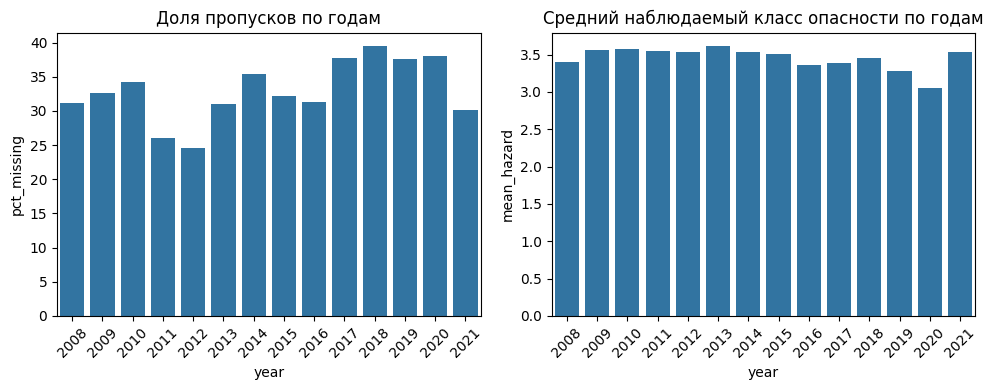

In [18]:
# Для этого нужно преобразовать hazard_class в числа
df['hazard_num'] = pd.to_numeric(df['hazard_class'], errors='coerce')

# Сгруппируем данные по какому-либо признаку, например, по годам, и посмотрим на долю пропусков и средний класс
grouped = df.groupby('year').agg({
    'hazard_num': ['mean', 'count'],
    'hazard_missing': 'sum'
}).reset_index()
grouped.columns = ['year', 'mean_hazard', 'n_obs', 'n_missing']
grouped['pct_missing'] = grouped['n_missing'] / (grouped['n_obs'] + grouped['n_missing']) * 100
grouped = grouped.sort_values('pct_missing', ascending=False)

print("Доля пропусков и средний наблюдаемый класс опасности по годам:")
print(grouped)

# Визуализация
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(x='year', y='pct_missing', data=grouped)
plt.title('Доля пропусков по годам')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(x='year', y='mean_hazard', data=grouped)
plt.title('Средний наблюдаемый класс опасности по годам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### **Полученные данные не дают оснований подозревать MNAR. Скорее, они согласуются с MAR: пропуски определяются годом (и, возможно, другими признаками), но не самим пропущенным значением**

## Задание 3. Индикатор пропуска как источник информации

### 2.3.1 Когда факт пропуска несёт информацию?

- ##### **Если причина пропуска связана с самим явлением, а не случайна**
##### **Пример: в наших данных у hazard_class пропуски могут означать, что для вещества класс опасности вообще не установлен**

### 2.3.2 Почему значимость индикатора в модели - сигнал о плохой замене пропусков?

- ##### **Мы заполнили пропуски (например, средним) и добавили столбец-флажок «был пропуск». Если этот флажок оказался важным для предсказаний, значит, наша замена была неточной - мы потеряли полезную информацию. Хорошая замена должна делать флажок ненужным**

### 2.3.3 Примеры

- ##### **Полезен: Признак: hazard_class (класс опасности)**
##### **В наших данных много пропусков (2627). Они не случайны, а связаны, например, с тем, что для некоторых веществ класс опасности не установлен. Добавив индикатор пропуска (1 — класс отсутствует, 0 — есть), мы даём модели возможность учесть эту особенность. Например, вещества без класса могут чаще оказываться в «подозрительных» выбросах**

- ##### **Бесполезен: Признак: value_min (минимальное значение)**
##### **Здесь всего 1 пропуск на 7671 запись. Скорее всего, это случайная опечатка или сбой. Такой единичный пропуск не связан с системой — он ничего не говорит о качестве воды. Если мы создадим для него индикатор, он будет практически всегда равен 0 и не даст модели никакой полезной информации**

- ##### **Опасен: Признак: value_min (гипотетически)**
##### **Представим, что пропусков в value_min было бы много, и они возникали бы из-за того, что концентрация вещества слишком мала и прибор её не зафиксировал (значение ниже порога обнаружения). Тогда сам факт пропуска означает «очень низкое значение». Если мы заменим пропуски, например, на ноль и добавим индикатор, модель быстро выучит: индикатор = 1 - значение маленькое. На новых данных, где порог обнаружения мог измениться, такая модель даст сбой, потому что индикатор перестанет соответствовать реальности. Индикатор становится подсказкой, которая не отражает истинной природы данных**

---
# 3 Выбросы
## Задание 4. Выброс - это ошибка или сигнал?

##### **Выберем признак value_min и конкретный выброс:**
##### **Значение 74 000 ПДК (запись ID 2215, Пермский край, марганец, август 2012, класс опасности 4)**

### 3.4.1 Какие реальные причины могут объяснить это значение?

#### **Такое аномально высокое число может быть:**

- ##### **Ошибкой при вводе данных. Например, вместо «7,4» или «740» случайно добавили лишний ноль (или два). Такое часто бывает при ручном заполнении**

- ##### **Сбоем измерительного прибора - если прибор дал сбой и зафиксировал нереальный результат**

- ##### **Реальным экстремальным загрязнением — теоретически возможно при аварийном сбросе, но 74 000 ПДК для марганца — это запредельный уровень, вряд ли зафиксированный официально. Обычно максимальные превышения — сотни, редко тысячи ПДК**

- ##### **Особенностью единиц измерения — например, если значение записано в мг/л, а не в ПДК, но в столбеце unit везде «ПДК», так что маловероятно**

### 3.4.2 Что хуже для анализа:

##### **Удалить выброс**
- ##### **Если это ошибка, удаление — лучший вариант. Оно уберёт искажение, и остальные данные останутся чистыми. В нашем случае это, скорее всего, правильное решение**

##### **Оставить без изменений**
- ##### **Хуже всего. Такое значение сделает среднее бессмысленным, сильно растянет шкалу на графиках, а модель будет пытаться подстроиться под эту аномалию. Все выводы исказятся**

##### **Применить преобразование (например, логарифмирование)**
- ##### **Логарифмирование уменьшит влияние выброса, но не уберёт его полностью. После логарифма 74 000 превратится в ~11,2, что всё равно будет сильно выше остальных (у которых логарифм, например, 1–4). Проблема останется, хоть и станет менее заметной. Если это ошибка, лучше просто удалить**

---
# 4 Статистики
## Задание 5. Преобразование или винзоризация?

### 4.5.1 В каких случаях что предпочтительнее?

##### **Логарифмирование**
##### **Используем, когда данные имеют сильный положительный скос и есть большие выбросы, которые нужно «прижать». Логарифм сжимает большие значения сильнее, чем маленькие, и распределение становится более симметричным. Подходит, если данные строго положительные (у нас ПДК > 0)**
- ##### Пример: наш value_min с выбросом 74000 — после логарифма станет около 11,2, а обычные значения (например, 1–10) превратятся в 0–2,3.  Разброс уменьшится, но выброс всё ещё будет выделяться, хотя и не так катастрофично.

##### **Корень**
##### **Действует слабее, чем логарифм. Подходит для умеренной асимметрии, когда значения не слишком велики. Корень тоже сжимает большие числа, но не так сильно. Может быть полезен, если среди данных есть нули (логарифм от нуля не определён)**
- ##### Пример: если бы у нас были значения до 1000, корень бы работал хорошо. Для 74000 корень будет ~272, что всё равно сильно выше остальных (корень от 1–10 = 1–3,2). Эффект слабый.

##### **Винзоризация**
##### **Это не преобразование, а замена крайних значений на определённые процентили (например, все значения выше 95-го процентиля заменяем на значение 95-го процентиля). Применяется, когда мы хотим устранить влияние выбросов, но не хотим их удалять. Подходит, если выбросы — это «шум», а не полезный сигнал, и мы хотим сохранить объём выборки**
- ##### Пример: заменим все value_min выше 99-го процентиля на значение 99-го процентиля. Выброс 74000 исчезнет, распределение станет компактным. Но мы потеряем информацию о том, что были экстремально высокие значения (если они реальны).

### 4.5.2 Как подходы влияют на интерпретируемость, линейные модели и визуализацию?

| Подход           | Интерпретируемость                                                                                                                                 | Линейные модели                                                                 | Визуализация                                                                 |
|------------------|----------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------|------------------------------------------------------------------------------|
| **Логарифмирование** | Масштаб меняется: вместо исходных ПДК анализируем **log(ПДК)**. Это позволяет увидеть порядки величин. | Сильно улучшает: уменьшает разброс, делает связи более линейными, выбросы перестают доминировать. Модели становятся устойчивее. | Гистограмма становится симметричной, «хвост» подтягивается. Легко увидеть основные группы данных. |
| **Корень**           | Новый масштаб — **корень из(ПДК)**. Интерпретировать чуть проще, чем логарифм                                       | Помогает слабее логарифма, но при умеренной асимметрии может быть достаточен.  | Распределение становится более симметричным, но очень большие выбросы всё ещё могут торчать. |
| **Винзоризация**     | **Единицы измерения сохраняются** (те же ПДК), но мы заменяем крайние значения на пороговые. Это искажает реальные максимумы, но если выбросы - ошибки, то оправдано. | Выбросы перестают влиять, коэффициенты становятся стабильнее. Если выбросы — сигналы, модель их потеряет. | Выбросы исчезают, шкала сжимается, распределение выглядит «обрезанным». Хорошо видно основную массу, но «хвосты» не видны. |

## Задание 6. Средние, которые вводят в заблуждение

***Для анализа выберем числовой признак value_min (минимальное значение загрязнения в ПДК)***

### 4.6.1 Сравнение арифметического, медианы и геометрического среднего

##### **Вычислим эти статистики для value_min, предварительно удалив пропуски (их всего 1) и убедившись, что все значения положительные (геометрическое среднее требует строго положительных чисел). Если есть нули, геометрическое станет нулём, но в наших данных, скорее всего, все значения > 0, так как концентрация не может быть нулевой.**

In [20]:
# Подготовка данных
val = df['value_min'].dropna()  # убираем пропуски
# Проверим, есть ли нули или отрицательные
print(f"Минимальное значение: {val.min()}")
print(f"Все значения положительные? { (val > 0).all() }")

# Вычисляем средние
mean_arith = val.mean()
median = val.median()
# Геометрическое среднее: exp(среднее от логарифмов)
mean_geom = np.exp(np.log(val).mean())

print(f"Арифметическое среднее: {mean_arith:.2f}")
print(f"Медиана: {median:.2f}")
print(f"Геометрическое среднее: {mean_geom:.2f}")

Минимальное значение: 0.0
Все значения положительные? False
Арифметическое среднее: 124.33
Медиана: 64.00
Геометрическое среднее: 0.00


/Users/a1/Desktop/Программы/iad-lab1/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Почему они различаются 

- ##### **Арифметическое среднее учитывает абсолютные значения всех наблюдений. Огромный выброс (74000 ПДК) сильно увеличивает сумму, поэтому среднее получается завышенным (124.33)**

- ##### **Медиана - это значение, которое делит упорядоченный ряд пополам. На неё почти не влияют выбросы, поэтому она остаётся в области, где сосредоточена основная масса данных (64.00)** ##### 

- ##### **Геометрическое среднее не может быть корректно вычислено из-за нулей. Если бы нулей не было, оно было бы меньше арифметического, так как логарифмирование сжимает большие числа, но всё равно чувствительно к малым значениям. В данном случае оно бесполезно** #####

### Какое среднее лучше отражает «типичное» значение?

- ##### **Для сильно асимметричных распределений с выбросами и нулями медиана является наилучшей мерой «типичного» значения, так как она устойчива к экстремальным наблюдениям. В нашем случае медиана равна 64, что означает: половина измерений имеют значение меньше 64 ПДК, а половина — больше. Арифметическое среднее (124.33) завышено из-за редких, но очень больших выбросов, и не отражает реальную картину большинства случаев. Геометрическое среднее в данном контексте некорректно из-за нулей и неинформативно**

---
# 5 Визуализация как инструмент мышления

## Задание 7. Неправильная диаграмма

### 5.7.1 Какой тип диаграммы был бы хуже?

- ##### **Мы строили столбчатую диаграмму, показывающую долю пропусков в признаке hazard_class по годам. Для этих данных неудачным выбором была бы круговая диаграмма, где каждый год представлен сектором, размер которого соответствует доле пропусков в этом году**

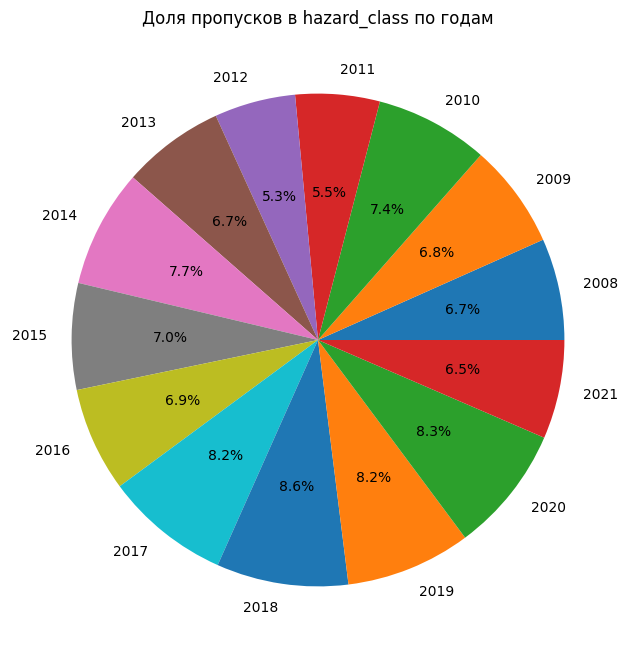

In [26]:
# Используем те же данные missing_by_year
plt.figure(figsize=(8, 8))
plt.pie(missing_by_year['pct_missing'], labels=missing_by_year['year'].astype(int), autopct='%1.1f%%')
plt.title('Доля пропусков в hazard_class по годам')
plt.show()

### 5.7.2 Описание

- #####  **Круговая диаграмма показывает доли от целого, то есть сумма всех секторов равна 100%. В нашем случае доли пропусков по годам — это не доли от общего числа пропусков, а самостоятельные показатели (процент пропусков внутри каждого года). Если бы мы построили круговую диаграмму, зритель воспринял бы её так, будто все эти доли в сумме составляют 100%, что бессмысленно.**

- ##### **На круговой диаграмме трудно сравнивать значения между годами, особенно если их много. Сектора с близкими размерами сложно различить на глаз, в отличие от столбцов, которые легко сравнивать по высоте.**

- ##### **Круговая диаграмма не передаёт временной порядок годов, тогда как на столбчатой диаграмме мы естественно располагаем годы по оси X, что позволяет увидеть тренд (рост или снижение доли пропусков).**

##### **Зритель мог бы подумать, что пропуски распределены по годам как части одного целого, например, что в 2018 году была самая большая «доля пропусков» в общем объёме пропусков за все годы, хотя на самом деле там просто высокий процент пропусков внутри этого года**

##### **Возможно, он сделал бы ошибочный вывод о том, что в годы с большим сектором пропусков было больше всего, хотя на самом деле это могло быть связано с разным общим количеством наблюдений по годам**

## Задание 8. Одна и та же информация - разные графики

##### **Для пары признаков год (year) и минимальное значение загрязнения (value_min) построим два разных графика, чтобы показать, как один и тот же набор данных может раскрывать разные аспекты**

### Гистограммы распределения value_min по отдельным годам

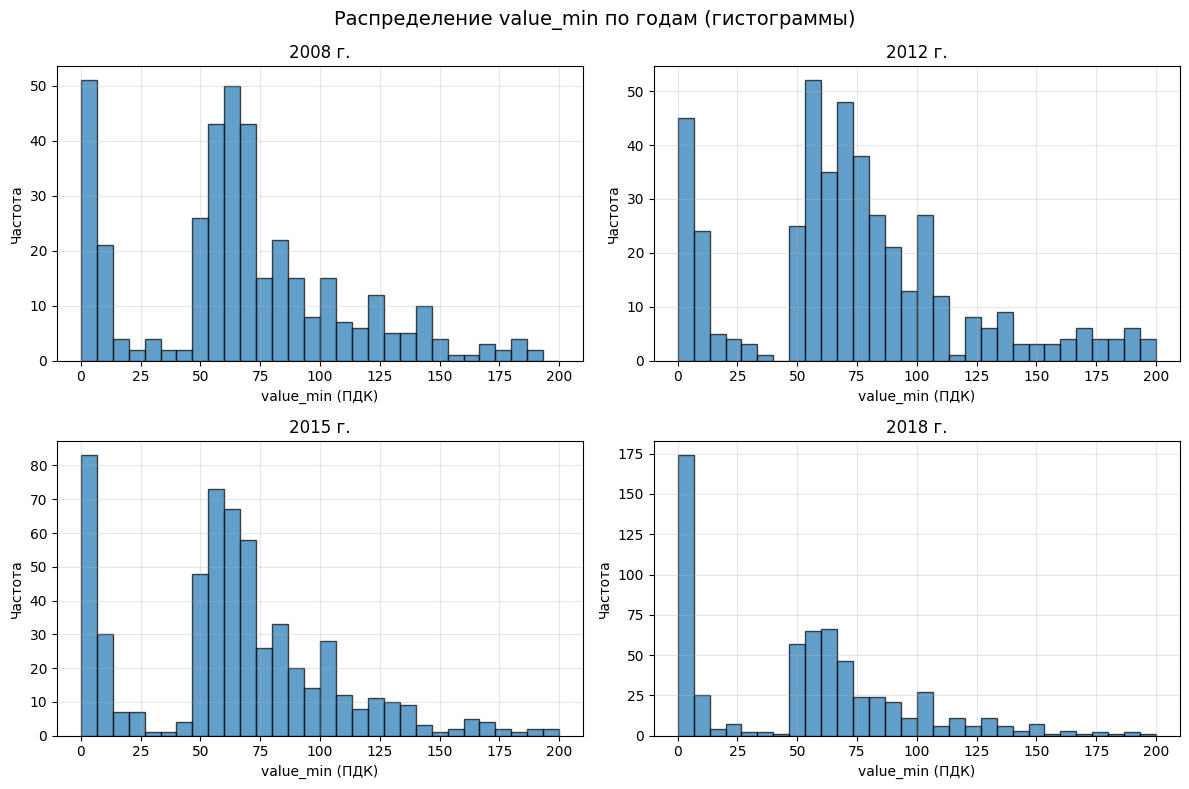

In [31]:
# Выберем несколько лет для наглядности
years_to_plot = [2008, 2012, 2015, 2018]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, year in enumerate(years_to_plot):
    data_year = df[df['year'] == year]['value_min'].dropna()
    # Ограничим ось X для лучшей читаемости (отсечём огромный выброс)
    axes[i].hist(data_year, bins=30, edgecolor='black', alpha=0.7, range=(0, 200))
    axes[i].set_title(f'{year} г.', fontsize=12)
    axes[i].set_xlabel('value_min (ПДК)')
    axes[i].set_ylabel('Частота')
    axes[i].grid(alpha=0.3)

plt.suptitle('Распределение value_min по годам (гистограммы)', fontsize=14)
plt.tight_layout()
plt.show()

#### **Какую информацию подчёркивают:**

- ##### **Показывают форму распределения, разброс, наличие пиков и выбросов внутри каждого года. Видно, где сосредоточена основная масса значений и как распределение меняется от года к году**

#### **Какие гипотезы легче заметить:**

- ##### **Например, что в 2012 году есть огромный выброс, не характерный для остальных лет, или что после 2012 года распределение смещается влево (значения становятся меньше). Но сложно оценить общий тренд среднего по всем годам**

### Линейный график среднего значения value_min по годам

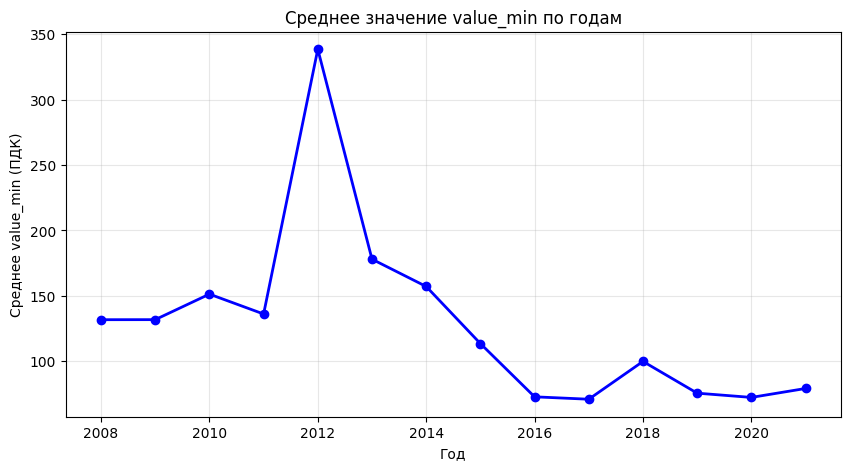

In [32]:
# Группируем по годам и считаем среднее
yearly_mean = df.groupby('year')['value_min'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_mean['year'], yearly_mean['value_min'], marker='o', linestyle='-', color='b', linewidth=2)
plt.title('Среднее значение value_min по годам')
plt.xlabel('Год')
plt.ylabel('Среднее value_min (ПДК)')
plt.grid(True, alpha=0.3)
plt.show()

#### **Какую информацию подчёркивает:**

- ##### **Показывает динамику среднего уровня загрязнения по годам, позволяет увидеть тренды (рост, спад), пики и спады средней величины**

#### **Какие гипотезы легче заметить:**

- ##### **Легко увидеть резкий скачок среднего в 2012 году и постепенное снижение после него. Однако не видно, что этот скачок вызван единичным выбросом, а не общим повышением, — для этого нужны гистограммы**

## *Гистограммы помогают понять структуру данных внутри каждого года, а линейный график — общую тенденцию. Вместе они дают полную картину*